Kategori A: Rata-rata Jam Belajar
education_level uses_ai  study_hours_per_day
        college      No             3.103571
        college     Yes             2.980000
         school      No             3.081250
         school     Yes             2.680000 

Kategori B: Penurunan Nilai (School)
0 Data (Tidak ada siswa sekolah yang nilainya turun).

Kategori C: Korelasi Jam Belajar vs Nilai Awal
School: 0.0004 | College: 0.3989

Kategori D: Pengecekan Outlier
Jumlah Outlier: 0 data



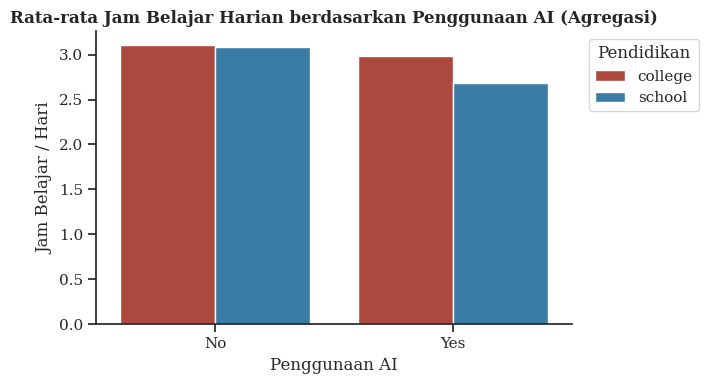

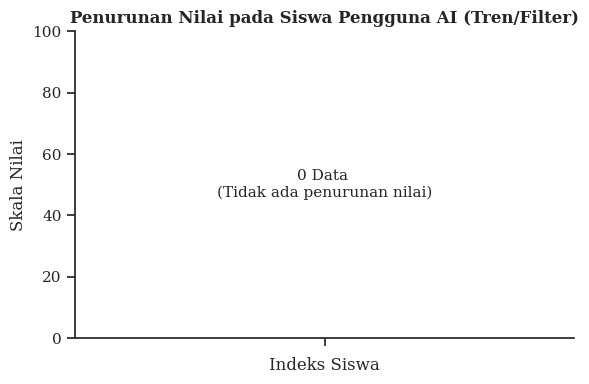

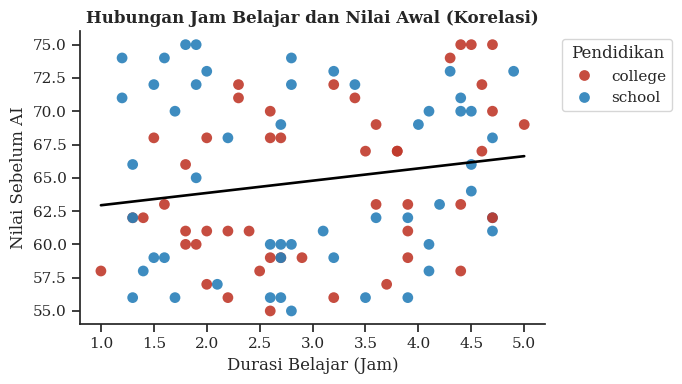

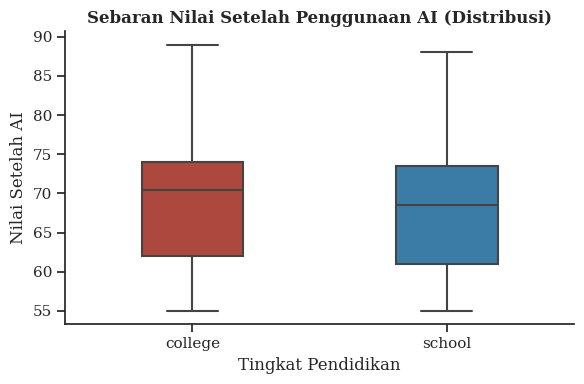

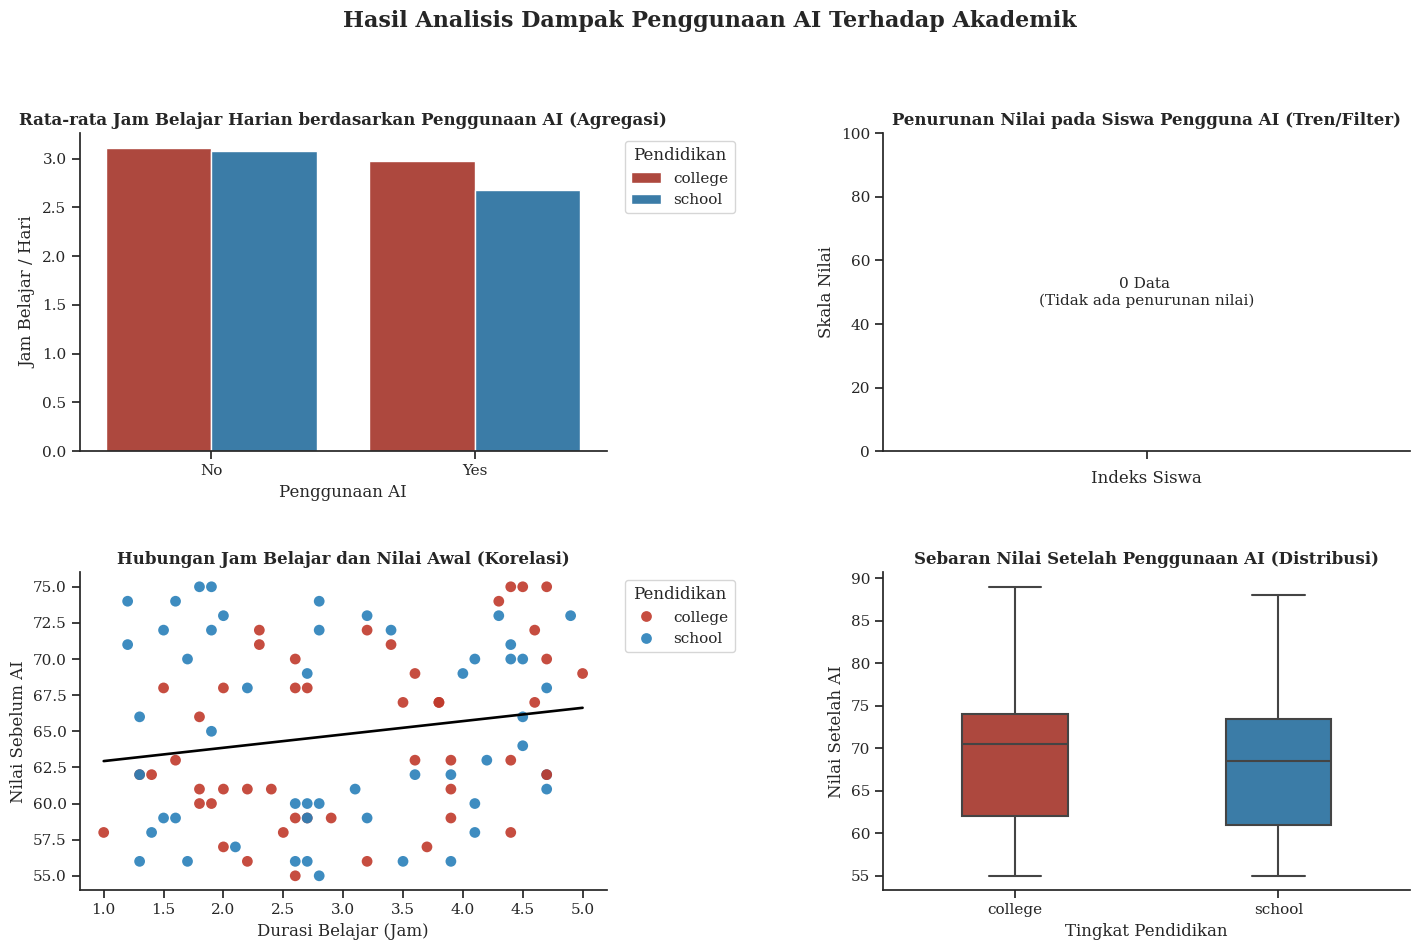

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = '/content/Kelas F_Student AI Usage.csv'
df = pd.read_csv(file_path)

sns.set_theme(style="ticks")
plt.rcParams['font.family'] = 'serif'
warna_pendidikan = {'school': '#2980b9', 'college': '#c0392b'}

df_agregasi = df.groupby(['education_level', 'uses_ai'], as_index=False)['study_hours_per_day'].mean()
print("Kategori A: Rata-rata Jam Belajar")
print(df_agregasi.to_string(index=False), "\n")

df_filter = df[(df['education_level'] == 'school') &
               (df['uses_ai'] == 'Yes') &
               (df['grades_after_ai'] < df['grades_before_ai'])]
print("Kategori B: Penurunan Nilai (School)")
if df_filter.empty:
    print("0 Data (Tidak ada siswa sekolah yang nilainya turun).\n")
else:
    print(df_filter.to_string(index=False), "\n")

corr_school = df[df['education_level'] == 'school']['study_hours_per_day'].corr(df[df['education_level'] == 'school']['grades_before_ai'])
corr_college = df[df['education_level'] == 'college']['study_hours_per_day'].corr(df[df['education_level'] == 'college']['grades_before_ai'])
print("Kategori C: Korelasi Jam Belajar vs Nilai Awal")
print(f"School: {corr_school:.4f} | College: {corr_college:.4f}\n")

Q1 = df['grades_after_ai'].quantile(0.25)
Q3 = df['grades_after_ai'].quantile(0.75)
batas_bawah = Q1 - 1.5 * (Q3 - Q1)
batas_atas = Q3 + 1.5 * (Q3 - Q1)
df_outlier = df[(df['grades_after_ai'] < batas_bawah) | (df['grades_after_ai'] > batas_atas)]
print("Kategori D: Pengecekan Outlier")
print(f"Jumlah Outlier: {len(df_outlier)} data\n")

def plot_agregasi(ax):
    sns.barplot(data=df, x='uses_ai', y='study_hours_per_day', hue='education_level',
                estimator='mean', errorbar=None, palette=warna_pendidikan, ax=ax)
    ax.set_title('Rata-rata Jam Belajar Harian berdasarkan Penggunaan AI (Agregasi)', fontweight='bold')
    ax.set_xlabel('Penggunaan AI')
    ax.set_ylabel('Jam Belajar / Hari')
    sns.despine(ax=ax)
    ax.legend(title='Pendidikan', bbox_to_anchor=(1.02, 1), loc='upper left')

def plot_tren(ax):
    if not df_filter.empty:
        df_filter[['grades_before_ai', 'grades_after_ai']].plot(kind='bar', ax=ax, color=['#7f8c8d', '#e74c3c'])
    else:
        ax.bar([''], [0])
        ax.set_ylim(0, 100)
        ax.text(0, 50, '0 Data \n(Tidak ada penurunan nilai)', ha='center', va='center', fontsize=11)
    ax.set_title('Penurunan Nilai pada Siswa Pengguna AI (Tren/Filter)', fontweight='bold')
    ax.set_xlabel('Indeks Siswa')
    ax.set_ylabel('Skala Nilai')
    sns.despine(ax=ax)

def plot_korelasi(ax):
    # Titik sebaran data (Scatter Plot)
    sns.scatterplot(data=df, x='study_hours_per_day', y='grades_before_ai', hue='education_level',
                    palette=warna_pendidikan, s=60, alpha=0.9, edgecolor='none', ax=ax)

    # Regresi Linier
    sns.regplot(data=df, x='study_hours_per_day', y='grades_before_ai',
                scatter=False, color='black', ci=None, line_kws={'linestyle': '-', 'linewidth': 1.9}, ax=ax)

    ax.set_title('Hubungan Jam Belajar dan Nilai Awal (Korelasi)', fontweight='bold')
    ax.set_xlabel('Durasi Belajar (Jam)')
    ax.set_ylabel('Nilai Sebelum AI')
    sns.despine(ax=ax)
    ax.legend(title='Pendidikan', bbox_to_anchor=(1.02, 1), loc='upper left')

def plot_distribusi(ax):
    sns.boxplot(data=df, x='education_level', y='grades_after_ai', hue='education_level',
                palette=warna_pendidikan, width=0.4, linewidth=1.5, ax=ax, legend=False)
    ax.set_title('Sebaran Nilai Setelah Penggunaan AI (Distribusi)', fontweight='bold')
    ax.set_xlabel('Tingkat Pendidikan')
    ax.set_ylabel('Nilai Setelah AI')
    sns.despine(ax=ax)

fig1, ax1 = plt.subplots(figsize=(7, 4))
plot_agregasi(ax1)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 4))
plot_tren(ax2)
plt.tight_layout()
plt.show()

fig3, ax3 = plt.subplots(figsize=(7, 4))
plot_korelasi(ax3)
plt.tight_layout()
plt.show()

fig4, ax4 = plt.subplots(figsize=(6, 4))
plot_distribusi(ax4)
plt.tight_layout()
plt.show()

fig5, axes = plt.subplots(2, 2, figsize=(15, 10))
fig5.suptitle('Hasil Analisis Dampak Penggunaan AI Terhadap Akademik', fontsize=16, fontweight='bold', y=0.98)

plot_agregasi(axes[0, 0])
plot_tren(axes[0, 1])
plot_korelasi(axes[1, 0])
plot_distribusi(axes[1, 1])

plt.tight_layout(pad=3.0, w_pad=5.0)
plt.show()